                            OLS Regression Results                            
Dep. Variable:         log_ai_patents   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.107
Method:                 Least Squares   F-statistic:                     24.97
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           1.16e-06
Time:                        17:43:02   Log-Likelihood:                -1004.1
No. Observations:                 817   AIC:                             2012.
Df Residuals:                     815   BIC:                             2022.
Df Model:                           1                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9428      0.055     17.070      0.0

c:\Users\dbvan\miniforge3\envs\dsc80Fresh\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 37, but rank is 35
  warnings.warn('covariance of constraints does not have full '
c:\Users\dbvan\miniforge3\envs\dsc80Fresh\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 38, but rank is 36
  warnings.warn('covariance of constraints does not have full '
c:\Users\dbvan\miniforge3\envs\dsc80Fresh\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 250, but rank is 21
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:         log_ai_patents   R-squared:                       0.772
Model:                            OLS   Adj. R-squared:                  0.672
Method:                 Least Squares   F-statistic:                     73.77
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           1.60e-89
Time:                        17:43:02   Log-Likelihood:                -446.02
No. Observations:                 817   AIC:                             1394.
Df Residuals:                     566   BIC:                             2575.
Df Model:                         250                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.9493    

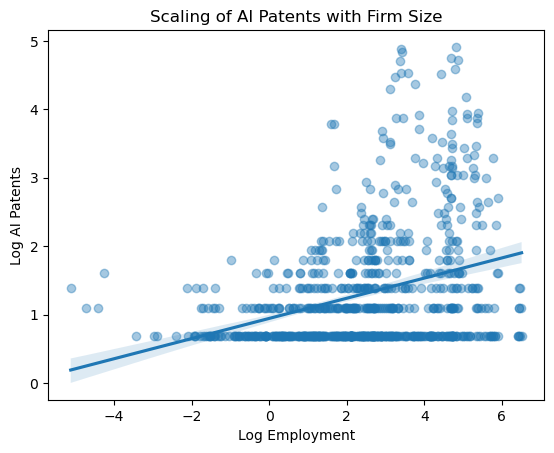

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.iolib.summary2 import summary_col

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)


df = pd.read_csv("FINAL CSV-AIP 197.csv")

df["datadate"] = pd.to_datetime(df["datadate"])

#basic drops

df = df.dropna(subset=["emp","revt","ppent","at"])

df["xrd"] = df["xrd"].fillna(0)

df = df[(df["emp"] > 0) & (df["revt"] > 0) & (df["at"] > 0)]

#log clarifications

df["log_emp"] = np.log(df["emp"])
df["log_assets"] = np.log(df["at"])
df["log_revenue"] = np.log(df["revt"])

df["log_ai_patents"] = np.log1p(df["ai_patent_count"])

#intesnity clarifications

df["rd_intensity"] = df["xrd"] / df["revt"]
df["capital_intensity"] = df["ppent"] / df["at"]
df["capx_intensity"] = df["capx"] / df["at"]

#winsor

for col in ["rd_intensity","capital_intensity","capx_intensity"]:
    
    lower = df[col].quantile(.01)
    upper = df[col].quantile(.99)
    
    df[col] = df[col].clip(lower, upper)


df["naics2"] = df["naics"].astype(str).str[:2]

#dropna

df = df.dropna(subset=[
    "log_emp",
    "log_ai_patents",
    "rd_intensity",
    "capital_intensity",
    "capx_intensity"
])

#OLS

model1 = smf.ols(
    "log_ai_patents ~ log_emp",
    data=df
).fit(cov_type="cluster", cov_kwds={"groups": df["gvkey"]})

print(model1.summary())

#OLS V2

model2 = smf.ols(
    "log_ai_patents ~ log_emp + rd_intensity + capital_intensity + capx_intensity",
    data=df
).fit(cov_type="cluster", cov_kwds={"groups": df["gvkey"]})

print(model2.summary())

#VIF

X = df[["log_emp","rd_intensity","capital_intensity","capx_intensity"]]

X = sm.add_constant(X)

vif = pd.DataFrame()

vif["variable"] = X.columns

vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

#industry and year fixed effects

model3 = smf.ols(
    "log_ai_patents ~ log_emp + rd_intensity + capital_intensity + capx_intensity + C(naics2) + C(fyear)",
    data=df
).fit(cov_type="cluster", cov_kwds={"groups": df["gvkey"]})

print(model3.summary())

#centered model

df["log_emp_centered"] = df["log_emp"] - df["log_emp"].mean()
df["log_emp_centered_sq"] = df["log_emp_centered"] ** 2

model4 = smf.ols(
    "log_ai_patents ~ log_emp_centered + log_emp_centered_sq + rd_intensity + capital_intensity + capx_intensity + C(naics2) + C(fyear)",
    data=df
).fit(cov_type="cluster", cov_kwds={"groups": df["gvkey"]})

print(model4.summary())

#FE 

model_fe = smf.ols(
    "log_ai_patents ~ log_emp_centered + log_emp_centered_sq + rd_intensity + capital_intensity + capx_intensity + C(gvkey) + C(fyear)",
    data=df
).fit(cov_type="cluster", cov_kwds={"groups": df["gvkey"]})

print(model_fe.summary())

#elasticity at mean firm size

elasticity_mean = model4.params["log_emp_centered"]

print("Elasticity at Mean Firm Size:", elasticity_mean)

#poisson model

poisson_model = smf.glm(
    "ai_patent_count ~ log_emp + rd_intensity + capital_intensity + capx_intensity + C(naics2) + C(fyear)",
    data=df,
    family=sm.families.Poisson()
).fit(cov_type="cluster", cov_kwds={"groups": df["gvkey"]})

print(poisson_model.summary())


#Regression table


summary = summary_col(
    [model1, model2, model3, model4, model_fe],
    stars=True,
    float_format="%0.3f",
    model_names=["Baseline","Controls","Industry-Year FE","Nonlinear","Firm FE Nonlinear"],
    info_dict={
        "N":lambda x: f"{int(x.nobs)}",
        "R2":lambda x: f"{x.rsquared:.3f}"
    }
)

print(summary)



#plot

import seaborn as sns

sns.regplot(
    x="log_emp",
    y="log_ai_patents",
    data=df,
    scatter_kws={"alpha":0.4}
)

plt.title("Scaling of AI Patents with Firm Size")
plt.xlabel("Log Employment")
plt.ylabel("Log AI Patents")

plt.show()

In [ ]:
#Poisson Regression Coefficients Table
poisson_coef = poisson_model.params
poisson_se = poisson_model.bse

#significance
def sig_stars(pval):
    if pval < 0.01:
        return "***"
    elif pval < 0.05:
        return "**"
    elif pval < 0.1:
        return "*"
    else:
        return ""
poisson_pvals = poisson_model.pvalues
stars = [sig_stars(p) for p in poisson_pvals]

# df
poisson_table = pd.DataFrame({
    "Coefficient": poisson_coef,
    "Std. Error": poisson_se,
    "Significance": stars
})

# keys
poisson_table_main = poisson_table.loc[["log_emp","rd_intensity","capital_intensity","capx_intensity"]]

print("\nPoisson Regression Table (Selected Variables):")
print(poisson_table_main)


Poisson Regression Table (Selected Variables):
                   Coefficient  Std. Error Significance
log_emp                  0.621       0.085          ***
rd_intensity             0.684       0.172          ***
capital_intensity       -0.741       1.413             
capx_intensity           6.176       4.036             
